# Alignment Experiments

This notebook demonstrates different alignment configurations for template-based document processing.

## Pre-Alignment Baseline: Original Differences
This shows the differences between template and input BEFORE any alignment processing.
Use this to understand how misaligned the input document is initially.

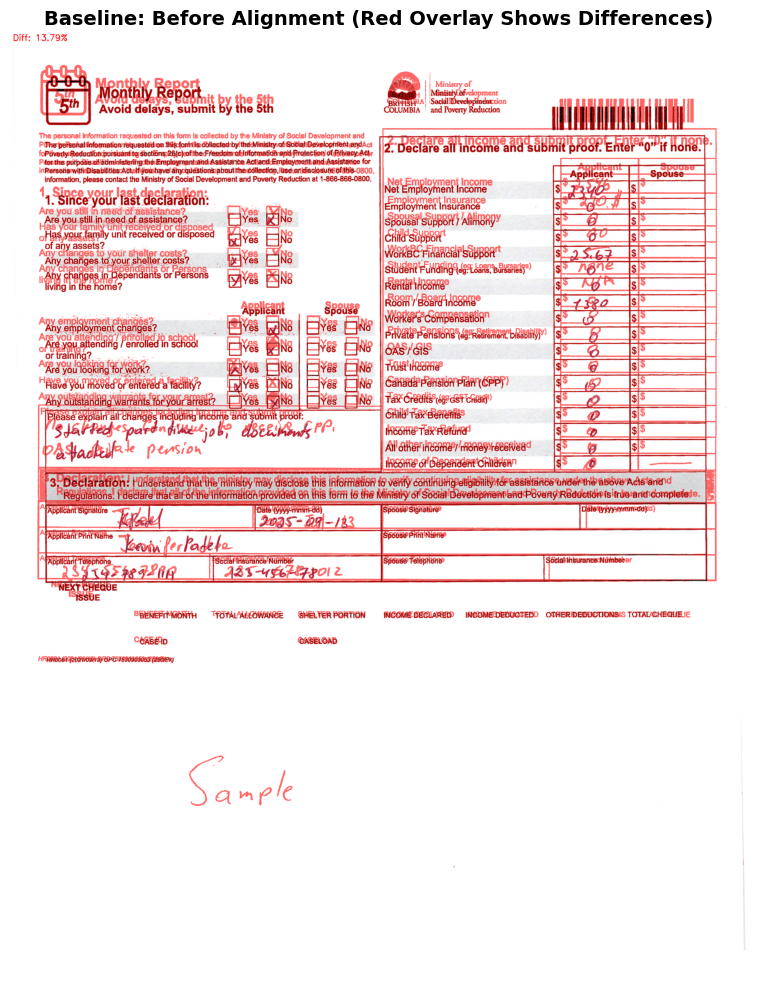

In [2]:
from pathlib import Path
import sys

# Find project root by looking for src/ directory
project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent

sys.path.insert(0, str(project_root))

# Define path constants
DATA_DIR = project_root / 'data'
TEMPLATES_DIR = DATA_DIR / 'templates'
INPUTS_DIR = DATA_DIR / 'inputs'
OUTPUTS_DIR = project_root / 'outputs'
VISUALIZATIONS_DIR = OUTPUTS_DIR / 'visualizations'

import cv2
import matplotlib.pyplot as plt
from src.visualization.diff_visualization import create_red_overlay_diff

# Load images for baseline comparison
template = cv2.imread(str(TEMPLATES_DIR / 'template.jpg'))
input_img = cv2.imread(str(INPUTS_DIR / 'input_document.jpg'))

# Generate baseline red overlay diff - shows original misalignment
baseline_red_overlay = create_red_overlay_diff(
    template,
    input_img,
    threshold=30,
    alpha=0.6
)
cv2.imwrite(str(VISUALIZATIONS_DIR / 'baseline_before_alignment_red_overlay.jpg'), baseline_red_overlay)

# Display the baseline comparison
plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(baseline_red_overlay, cv2.COLOR_BGR2RGB))
plt.title('Baseline: Before Alignment (Red Overlay Shows Differences)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## Default (fast ORB)
Uses ORB with balanced settings: reasonably strict matching, standard RANSAC threshold, and a minimum of 10 matches.
Good general-purpose choice for clean scans where you want speed and reliability without tuning.

[INFO] Using ORB detector (Oriented FAST and Rotated BRIEF)
       Pros: 24x faster than SIFT, free license, efficient
       Cons: Less robust to extreme rotations (>45°)

PHASE 1: GLOBAL FEATURE-BASED REGISTRATION

[STEP 1.1] Feature Detection and Matching
[INFO] Detected 5000 keypoints
[INFO] Detected 5000 keypoints
[INFO] Found 1002/5000 good matches (20.0%)

[STEP 1.2] Homography Computation (RANSAC)
[INFO] RANSAC found 783/1002 inliers (78.1%)
[INFO] Mean reprojection error: 1.73 pixels

[STEP 1.3] Image Warping and Registration
[INFO] Warped input image to template size: 2610x3348

----------------------------------------------------------------------
ALIGNMENT QUALITY METRICS:
----------------------------------------------------------------------
  ✓ Inlier ratio: 78.1% (target: >40%)
  ✓ Reprojection error: 1.73px (target: <5px)
  ✓ Total matches: 1002
  ✓ Inlier matches: 783

  Quality Checks:
    ✓ Sufficient matches: PASS
    ✓ Good inlier ratio: PASS
    ✓ Low reprojection

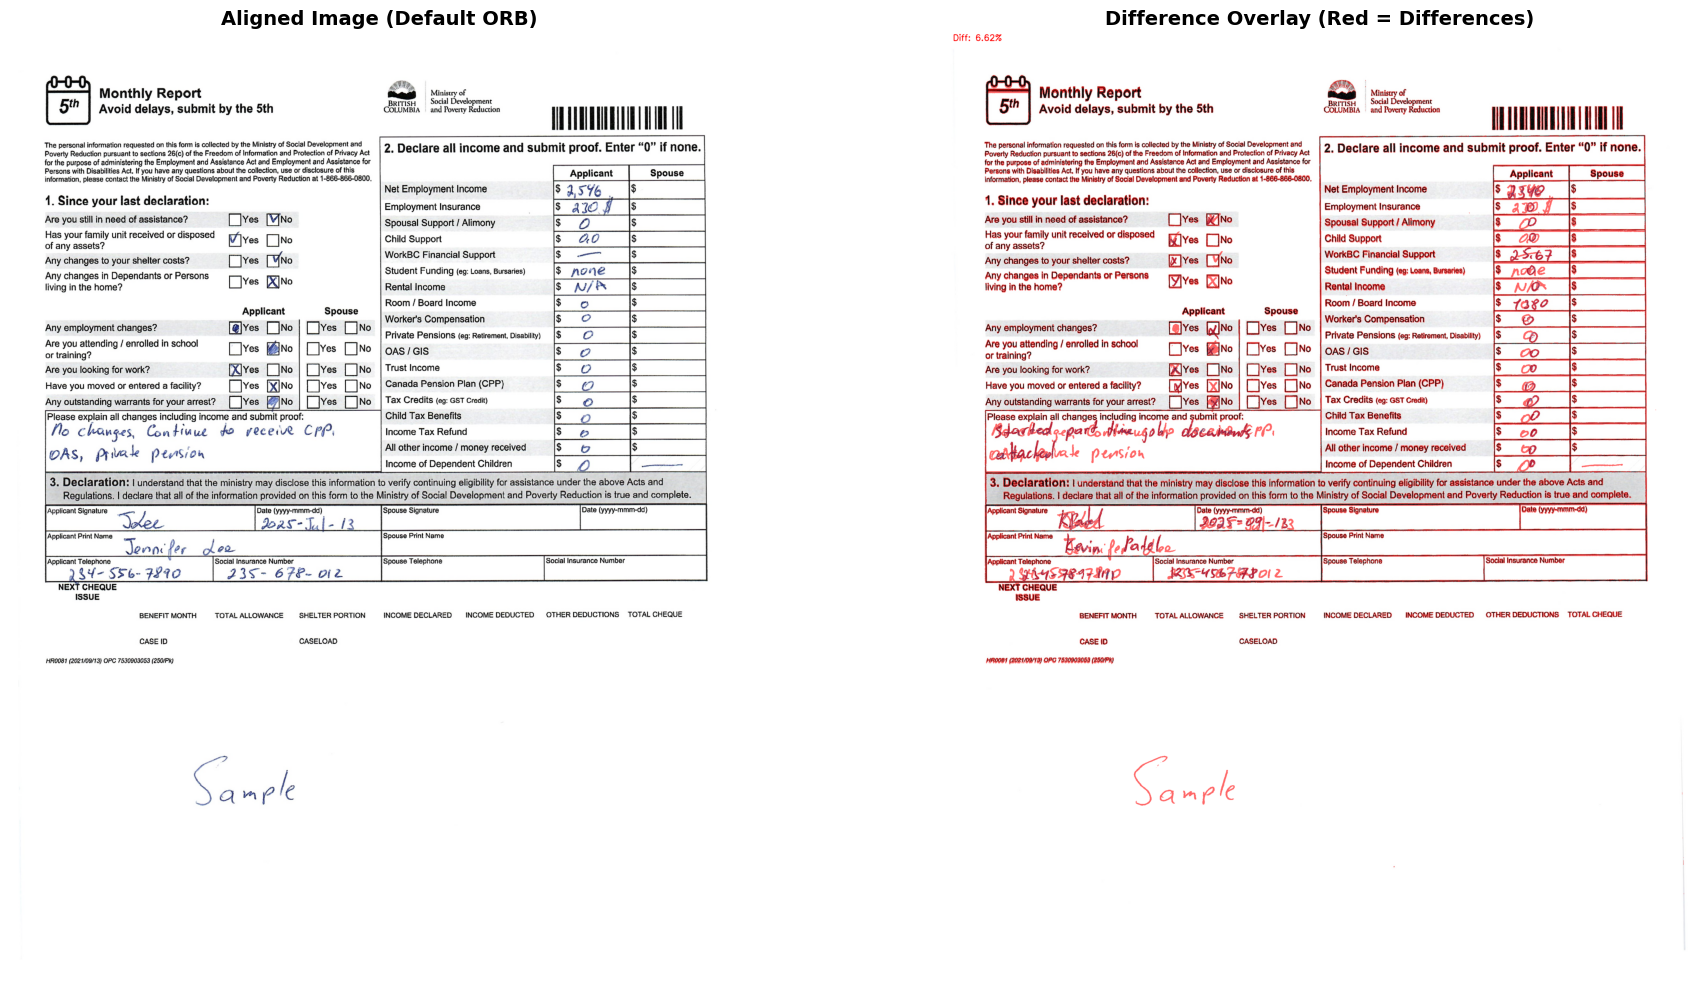

In [3]:
from pathlib import Path
import sys

# Find project root by looking for src/ directory
project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent

sys.path.insert(0, str(project_root))

# Define path constants
DATA_DIR = project_root / 'data'
TEMPLATES_DIR = DATA_DIR / 'templates'
INPUTS_DIR = DATA_DIR / 'inputs'
OUTPUTS_DIR = project_root / 'outputs'
VISUALIZATIONS_DIR = OUTPUTS_DIR / 'visualizations'

import cv2
import matplotlib.pyplot as plt
from src.alignment.phase_1_alignment import FeatureBasedAligner, AlignmentConfig
from src.visualization.diff_visualization import create_red_overlay_diff

template = cv2.imread(str(TEMPLATES_DIR / "template.jpg"))
input_img = cv2.imread(str(INPUTS_DIR / "input_document.jpg"))

config = AlignmentConfig(
    feature_detector="ORB",
    max_features=5000,
    ratio_test_threshold=0.7,
    ransac_threshold=5.0,
    min_matches=10,
    verbose=True,
)

aligner = FeatureBasedAligner(config)
result = aligner.align(input_img, template)

cv2.imwrite(str(VISUALIZATIONS_DIR / "aligned_default_orb.jpg"), result.aligned_image)

red_overlay = create_red_overlay_diff(template, result.aligned_image, threshold=30, alpha=0.6)
cv2.imwrite(str(VISUALIZATIONS_DIR / "aligned_default_orb_red_overlay.jpg"), red_overlay)

print(f"[DEFAULT] Error: {result.reprojection_error:.2f}px, Inliers: {result.inlier_ratio:.1f}%")

# Display results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(cv2.cvtColor(result.aligned_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Aligned Image (Default ORB)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(red_overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title('Difference Overlay (Red = Differences)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## High Accuracy (SIFT)
Switches to SIFT with otherwise standard thresholds.
Better when documents may be rotated, slightly distorted, or you want the most accurate homography and can afford extra runtime.

[INFO] Using SIFT detector (Scale-Invariant Feature Transform)
       Pros: Highest accuracy, rotation/scale invariant
       Cons: Slower (~1-3 seconds per image)

PHASE 1: GLOBAL FEATURE-BASED REGISTRATION

[STEP 1.1] Feature Detection and Matching
[INFO] Detected 30862 keypoints
[INFO] Detected 35257 keypoints
[INFO] Found 4599/30862 good matches (14.9%)

[STEP 1.2] Homography Computation (RANSAC)
[INFO] RANSAC found 3071/4599 inliers (66.8%)
[INFO] Mean reprojection error: 1.35 pixels

[STEP 1.3] Image Warping and Registration
[INFO] Warped input image to template size: 2610x3348

----------------------------------------------------------------------
ALIGNMENT QUALITY METRICS:
----------------------------------------------------------------------
  ✓ Inlier ratio: 66.8% (target: >40%)
  ✓ Reprojection error: 1.35px (target: <5px)
  ✓ Total matches: 4599
  ✓ Inlier matches: 3071

  Quality Checks:
    ✓ Sufficient matches: PASS
    ✓ Good inlier ratio: PASS
    ✓ Low reprojection er

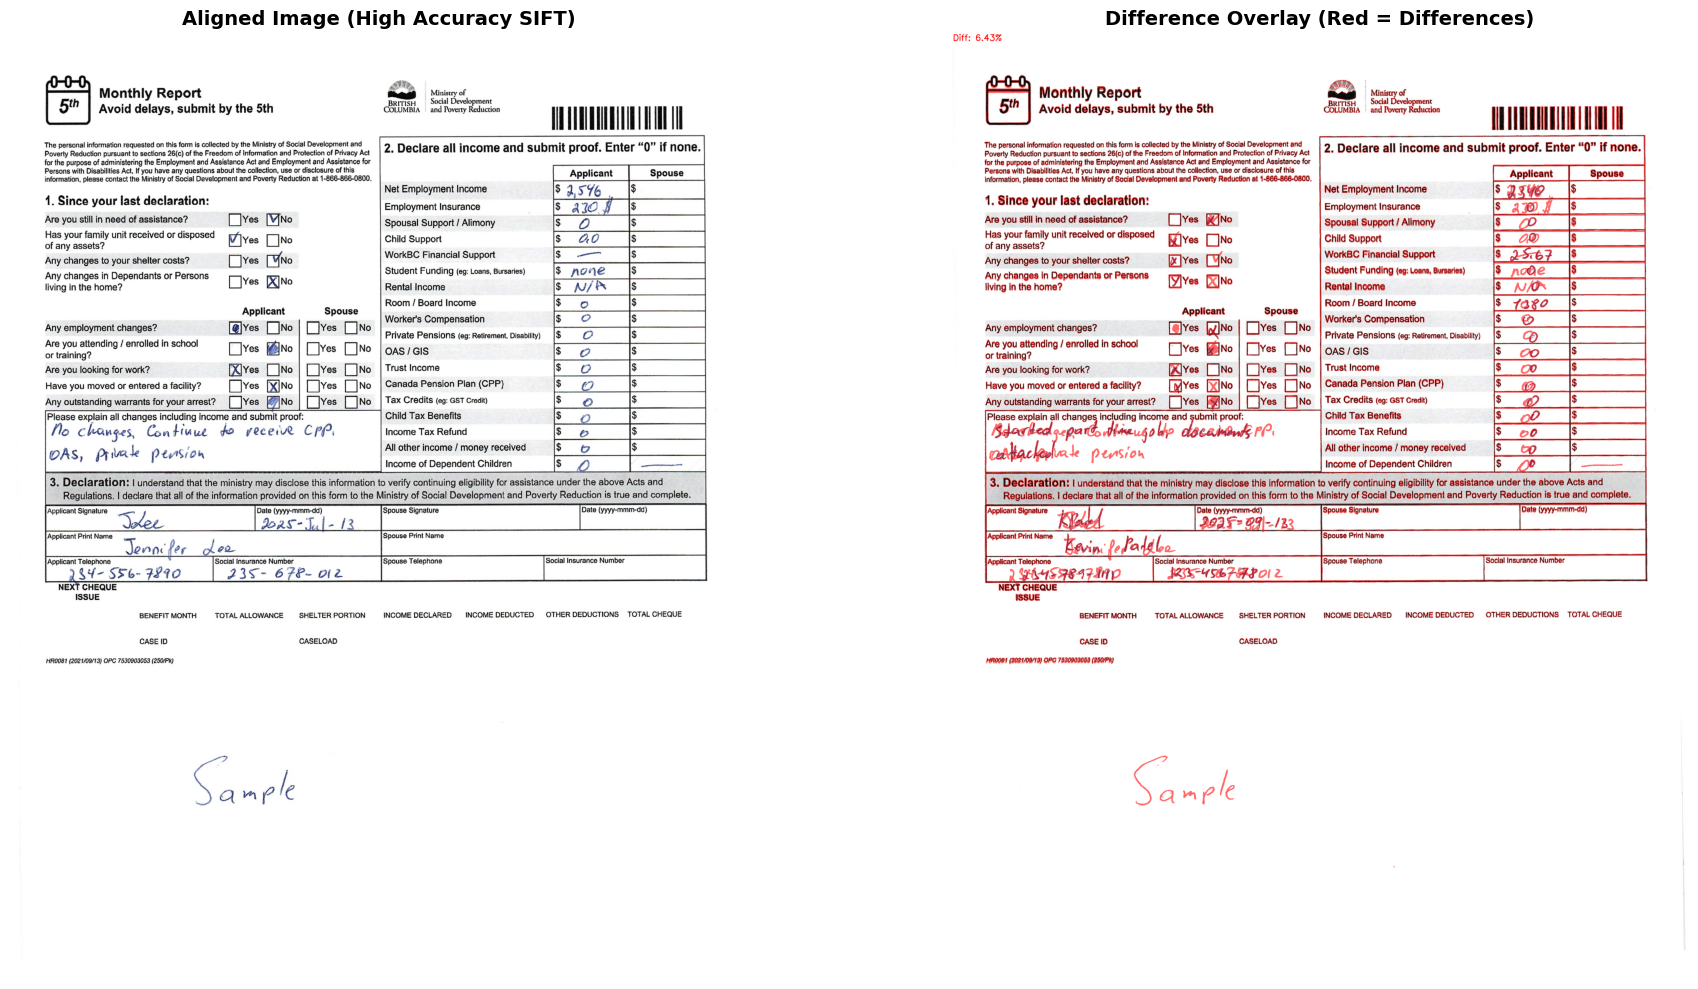

In [4]:
from pathlib import Path
import sys

# Find project root by looking for src/ directory
project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent

sys.path.insert(0, str(project_root))

# Define path constants
DATA_DIR = project_root / 'data'
TEMPLATES_DIR = DATA_DIR / 'templates'
INPUTS_DIR = DATA_DIR / 'inputs'
OUTPUTS_DIR = project_root / 'outputs'
VISUALIZATIONS_DIR = OUTPUTS_DIR / 'visualizations'

import cv2
import matplotlib.pyplot as plt
from src.alignment.phase_1_alignment import FeatureBasedAligner, AlignmentConfig
from src.visualization.diff_visualization import create_red_overlay_diff

template = cv2.imread(str(TEMPLATES_DIR / 'template.jpg'))
input_img = cv2.imread(str(INPUTS_DIR / 'input_document.jpg'))

# High-accuracy SIFT configuration
config = AlignmentConfig(
    feature_detector="SIFT",      # More accurate, slower
    max_features=5000,
    ratio_test_threshold=0.7,     # Standard Lowe ratio
    ransac_threshold=5.0,         # Standard RANSAC threshold
    min_matches=10,
    verbose=True
)

aligner = FeatureBasedAligner(config)
result = aligner.align(input_img, template)

cv2.imwrite(str(VISUALIZATIONS_DIR / 'aligned_accurate_sift.jpg'), result.aligned_image)

# Create red overlay diff
red_overlay = create_red_overlay_diff(
    template,
    result.aligned_image,
    threshold=30,
    alpha=0.6
)
cv2.imwrite(str(VISUALIZATIONS_DIR / 'aligned_accurate_sift_red_overlay.jpg'), red_overlay)

print(f"[ACCURATE SIFT] Error: {result.reprojection_error:.2f}px, Inliers: {result.inlier_ratio:.1f}%")

# Display results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(cv2.cvtColor(result.aligned_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Aligned Image (High Accuracy SIFT)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(red_overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title('Difference Overlay (Red = Differences)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Difficult Documents (relaxed, SIFT)
Still uses SIFT but relaxes the matching and RANSAC thresholds, and allows fewer matches while looking for more features.
Intended for low-contrast, noisy, partially visible, or otherwise "hard" documents where default settings fail due to too few inliers.

[INFO] Using SIFT detector (Scale-Invariant Feature Transform)
       Pros: Highest accuracy, rotation/scale invariant
       Cons: Slower (~1-3 seconds per image)

PHASE 1: GLOBAL FEATURE-BASED REGISTRATION

[STEP 1.1] Feature Detection and Matching
[INFO] Detected 30862 keypoints
[INFO] Detected 35257 keypoints
[INFO] Found 7949/30862 good matches (25.8%)

[STEP 1.2] Homography Computation (RANSAC)
[INFO] RANSAC found 3994/7949 inliers (50.2%)
[INFO] Mean reprojection error: 1.35 pixels

[STEP 1.3] Image Warping and Registration
[INFO] Warped input image to template size: 2610x3348

----------------------------------------------------------------------
ALIGNMENT QUALITY METRICS:
----------------------------------------------------------------------
  ✓ Inlier ratio: 50.2% (target: >40%)
  ✓ Reprojection error: 1.35px (target: <5px)
  ✓ Total matches: 7949
  ✓ Inlier matches: 3994

  Quality Checks:
    ✓ Sufficient matches: PASS
    ✓ Good inlier ratio: PASS
    ✓ Low reprojection er

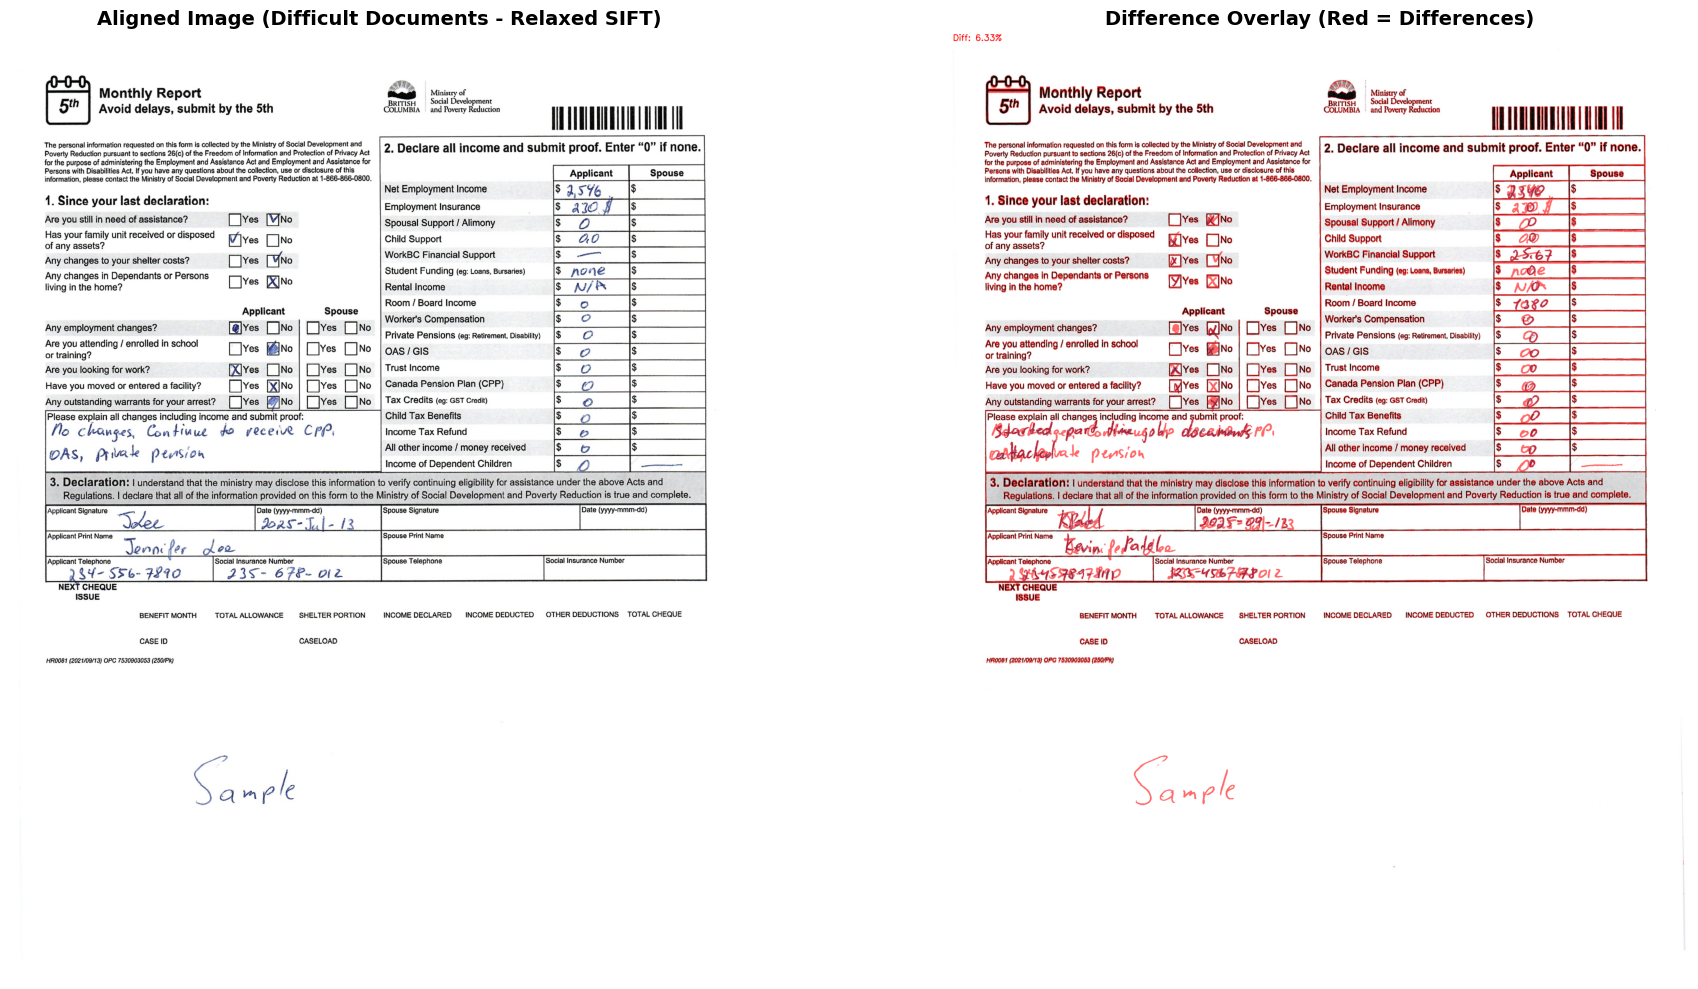

In [5]:
from pathlib import Path
import sys

# Find project root by looking for src/ directory
project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent

sys.path.insert(0, str(project_root))

# Define path constants
DATA_DIR = project_root / 'data'
TEMPLATES_DIR = DATA_DIR / 'templates'
INPUTS_DIR = DATA_DIR / 'inputs'
OUTPUTS_DIR = project_root / 'outputs'
VISUALIZATIONS_DIR = OUTPUTS_DIR / 'visualizations'

import cv2
import matplotlib.pyplot as plt
from src.alignment.phase_1_alignment import FeatureBasedAligner, AlignmentConfig
from src.visualization.diff_visualization import create_red_overlay_diff

template = cv2.imread(str(TEMPLATES_DIR / 'template.jpg'))
input_img = cv2.imread(str(INPUTS_DIR / 'input_document.jpg'))

# Relaxed config for low-contrast / noisy / partially visible docs
config = AlignmentConfig(
    feature_detector="SIFT",
    max_features=8000,            # Look for more features
    ratio_test_threshold=0.8,     # More lenient matching
    ransac_threshold=7.0,         # More tolerant RANSAC
    min_matches=8,                # Allow fewer matches
    verbose=True
)

aligner = FeatureBasedAligner(config)
result = aligner.align(input_img, template)

cv2.imwrite(str(VISUALIZATIONS_DIR / 'aligned_difficult.jpg'), result.aligned_image)

# Create red overlay diff
red_overlay = create_red_overlay_diff(
    template,
    result.aligned_image,
    threshold=30,
    alpha=0.6
)
cv2.imwrite(str(VISUALIZATIONS_DIR / 'aligned_difficult_red_overlay.jpg'), red_overlay)

print(f"[DIFFICULT] Error: {result.reprojection_error:.2f}px, Inliers: {result.inlier_ratio:.1f}%")

# Display results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(cv2.cvtColor(result.aligned_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Aligned Image (Difficult Documents - Relaxed SIFT)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(red_overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title('Difference Overlay (Red = Differences)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Strict Quality Control
Uses SIFT with stricter ratio test, tighter RANSAC threshold, and higher minimum matches.
Designed for production quality gates where you only accept very precise alignments and are okay with rejecting marginal cases.

[INFO] Using SIFT detector (Scale-Invariant Feature Transform)
       Pros: Highest accuracy, rotation/scale invariant
       Cons: Slower (~1-3 seconds per image)

PHASE 1: GLOBAL FEATURE-BASED REGISTRATION

[STEP 1.1] Feature Detection and Matching
[INFO] Detected 30862 keypoints
[INFO] Detected 35257 keypoints
[INFO] Found 3564/30862 good matches (11.5%)

[STEP 1.2] Homography Computation (RANSAC)
[INFO] RANSAC found 2469/3564 inliers (69.3%)
[INFO] Mean reprojection error: 1.19 pixels

[STEP 1.3] Image Warping and Registration
[INFO] Warped input image to template size: 2610x3348

----------------------------------------------------------------------
ALIGNMENT QUALITY METRICS:
----------------------------------------------------------------------
  ✓ Inlier ratio: 69.3% (target: >40%)
  ✓ Reprojection error: 1.19px (target: <5px)
  ✓ Total matches: 3564
  ✓ Inlier matches: 2469

  Quality Checks:
    ✓ Sufficient matches: PASS
    ✓ Good inlier ratio: PASS
    ✓ Low reprojection er

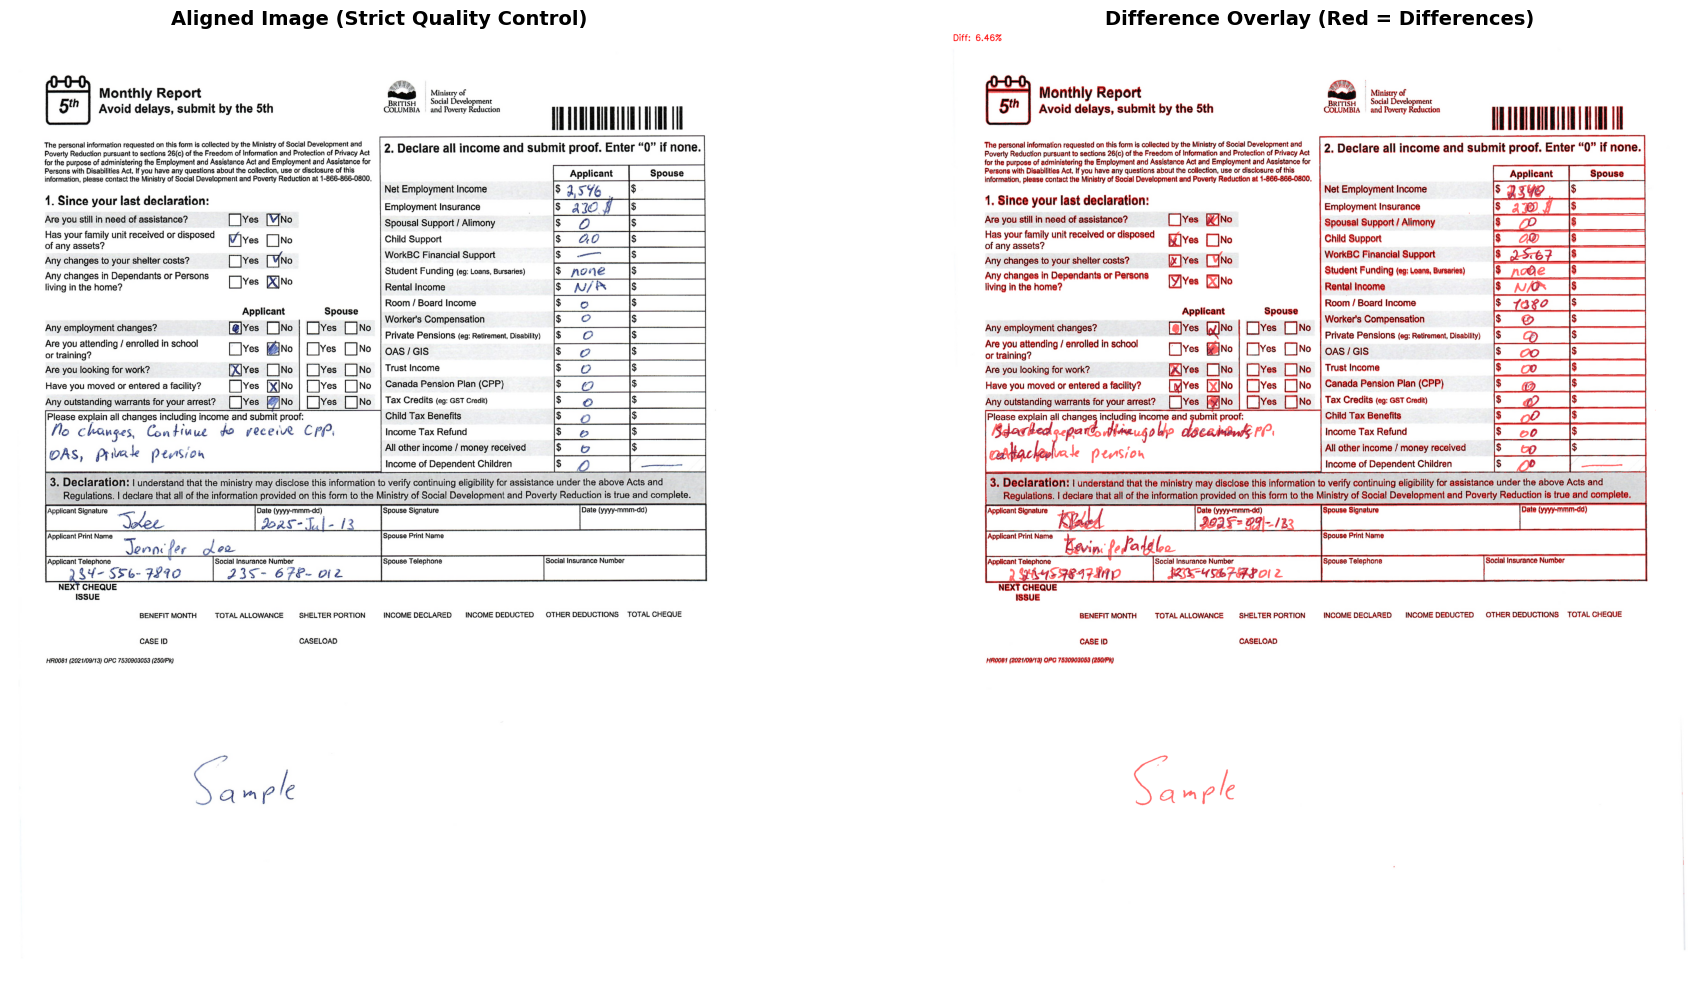

In [6]:
from pathlib import Path
import sys

# Find project root by looking for src/ directory
project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent

sys.path.insert(0, str(project_root))

# Define path constants
DATA_DIR = project_root / 'data'
TEMPLATES_DIR = DATA_DIR / 'templates'
INPUTS_DIR = DATA_DIR / 'inputs'
OUTPUTS_DIR = project_root / 'outputs'
VISUALIZATIONS_DIR = OUTPUTS_DIR / 'visualizations'

import cv2
import matplotlib.pyplot as plt
from src.alignment.phase_1_alignment import FeatureBasedAligner, AlignmentConfig
from src.visualization.diff_visualization import create_red_overlay_diff

template = cv2.imread(str(TEMPLATES_DIR / 'template.jpg'))
input_img = cv2.imread(str(INPUTS_DIR / 'input_document.jpg'))

# Strict configuration for QC (reject marginal alignments)
config = AlignmentConfig(
    feature_detector="SIFT",
    max_features=6000,
    ratio_test_threshold=0.65,    # Stricter Lowe ratio
    ransac_threshold=3.0,         # Tight inlier threshold
    min_matches=20,               # Require more matches
    verbose=True
)

aligner = FeatureBasedAligner(config)
result = aligner.align(input_img, template)

cv2.imwrite(str(VISUALIZATIONS_DIR / 'aligned_strict_qc.jpg'), result.aligned_image)

# Create red overlay diff
red_overlay = create_red_overlay_diff(
    template,
    result.aligned_image,
    threshold=30,
    alpha=0.6
)
cv2.imwrite(str(VISUALIZATIONS_DIR / 'aligned_strict_qc_red_overlay.jpg'), red_overlay)

print(f"[STRICT QC] Error: {result.reprojection_error:.2f}px, Inliers: {result.inlier_ratio:.1f}%")

# Optional simple pass/fail:
ok = (result.inlier_ratio > 50 and result.reprojection_error < 3)
print(f"[STRICT QC] PASS: {ok}")

# Display results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(cv2.cvtColor(result.aligned_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Aligned Image (Strict Quality Control)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(red_overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title('Difference Overlay (Red = Differences)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()